In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:

def plot_aimd(history_x1, history_x2, latest_x1, latest_x2,
              average_x1, average_x2, capacity, n_iterations,
              initial_x1, initial_x2, alpha1, alpha2, beta1, beta2,
              plot_title, plot2xy=None, plot3xy=None):

    fig = plt.figure(figsize=(7, 6.5), layout="constrained")
    plot1 = plt.subplot2grid((8, 2), (0, 0), colspan=2, rowspan=4)
    plot2 = plt.subplot2grid((8, 2), (4, 0), colspan=2, rowspan=2)
    plot3 = plt.subplot2grid((8, 2), (6, 0), colspan=2, rowspan=2)

    linear_x = np.linspace(0, capacity, capacity)
    plot1.plot(linear_x, linear_x, 'b--', label='Fairness Line')
    plot1.plot(linear_x, capacity - linear_x, color='orange', linestyle='--', label='Efficiency Line')
    plot1.plot(history_x1, history_x2, marker='.', color='black', markersize=3, linewidth=0.5)
    plot1.plot(latest_x1, latest_x2, 'go', markersize=8,
               label=f'Final peak value ({latest_x1:.2f}, {latest_x2:.2f})')
    plot1.set_xlim(0, capacity * 1.1)
    plot1.set_ylim(0, capacity)
    plot1.legend(loc='upper left')
    plot1.set_xlabel("User 1's Allocation $x_1$")
    plot1.set_ylabel("User 2's Allocation $x_2$")
    plot1.set_title(plot_title)
    plot1.annotate(
        f'Iterations: {n_iterations}\nCapacity: {capacity}\n'
        f'Initial $x_1$: {initial_x1}\nInitial $x_2$: {initial_x2}\n'
        f'$\\alpha_1$: {alpha1}\n$\\alpha_2$: {alpha2}\n'
        f'$\\beta_1$: {beta1}\n$\\beta_2$: {beta2}',
        xy=(0.78 * capacity, 0.05 * capacity)
    )

    # Congestion window x1
    rtt_values = np.linspace(0, n_iterations, len(history_x1))
    plot2.plot(rtt_values, history_x1, color='black', linewidth=1)
    plot2.set_xlabel('Number of Transmissions')
    plot2.set_ylabel('Congestion Window Size')
    plot2.set_title('Congestion Window for $x_1$')
    if plot2xy is None: plot2xy = (0.7 * n_iterations, latest_x1 / 2)
    plot2.annotate(f'Steady rate $x_1$: {average_x1:.2f}', xy=plot2xy)

    # Congestion window x2
    plot3.plot(rtt_values, history_x2, color='black', linewidth=1)
    plot3.set_xlabel('Number of Transmissions')
    plot3.set_ylabel('Congestion Window Size')
    plot3.set_title('Congestion Window for $x_2$')
    if plot3xy is None: plot3xy = (0.7 * n_iterations, latest_x2 / 2)
    plot3.annotate(f'Steady rate $x_2$: {average_x2:.2f}', xy=plot3xy)

    plt.savefig('aimd_simulation.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
def aimd(capacity, initial_x1, initial_x2, alpha1, alpha2, beta1, beta2, n_iterations):
    x1, x2 = initial_x1, initial_x2
    history_x1, history_x2 = [x1], [x2]
    latest_x1, latest_x2 = 0, 0
    fairness_iteration = 0
    decreased_iterations = []

    for i in range(n_iterations):
        # Additive increase
        if x1 + x2 <= capacity:
            x1 += alpha1
            x2 += alpha2
        else:
            # Multiplicative decrease
            latest_x1, latest_x2 = x1, x2
            decreased_iterations.append(i)

            if fairness_iteration == 0 and capacity/2 * 0.95 < latest_x2 < capacity/2 * 1.05 and capacity/2 * 0.95 < latest_x1 < capacity/2 * 1.05:
                fairness_iteration = i

            x1 *= beta1
            x2 *= beta2
        # Record history for plotting
        history_x1.append(x1)
        history_x2.append(x2)

    # Calculate steady rates based on the last few congestion events
    decreased_iterations = np.array(decreased_iterations)
    if len(decreased_iterations) > 4:
        window = decreased_iterations[-1] - decreased_iterations[-4]
        steady_x1 = sum(history_x1[int(decreased_iterations[-4]) : int(decreased_iterations[-1])])
        steady_x2 = sum(history_x2[int(decreased_iterations[-4]) : int(decreased_iterations[-1])])
        average_x1 = steady_x1 / window
        average_x2 = steady_x2 / window
    else:
        average_x1 = np.mean(history_x1)
        average_x2 = np.mean(history_x2)

    print(f"Total iterations: {n_iterations}")
    print(f"Close to fair value at iteration: {fairness_iteration}")
    print(f"Latest x1 and x2 before congestion: {latest_x1:.2f}, {latest_x2:.2f}")
    print(f"Steady rate x1: {average_x1:.2f}")
    print(f"Steady rate x2: {average_x2:.2f}")

    return history_x1, history_x2, latest_x1, latest_x2, average_x1, average_x2, fairness_iteration

Total iterations: 200
Close to fair value at iteration: 118
Latest x1 and x2 before congestion: 49.86, 50.16
Steady rate x1: 37.16
Steady rate x2: 37.88


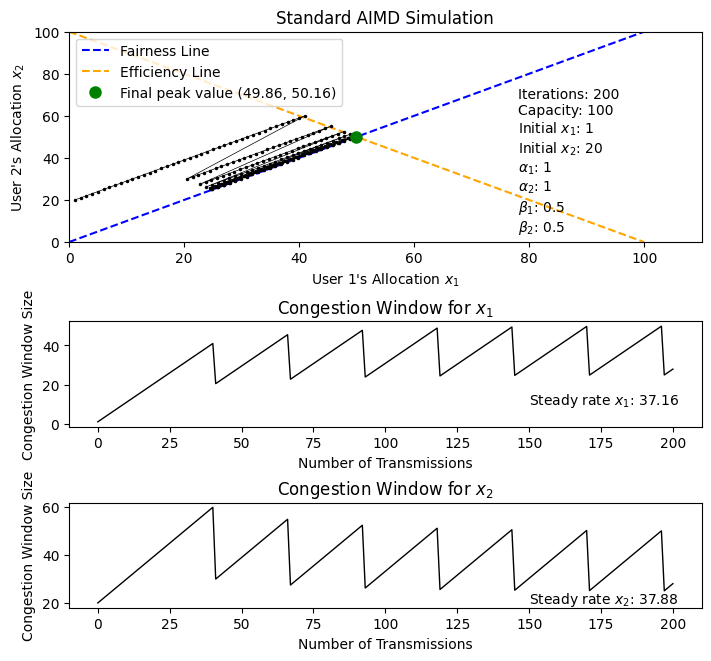

In [ ]:
# Run simulation with standard AIMD parameters
ITERATESMAX = 200
network_capacity = 100
initial_x1 = 1
initial_x2 = 20
alpha1 = alpha2 = 1
beta1 = beta2 = 0.5

history_x1, history_x2, latest_x1, latest_x2, average_x1, average_x2, fairness_iteration = aimd(
    network_capacity, initial_x1, initial_x2,
    alpha1, alpha2, beta1, beta2, ITERATESMAX
)

plot_aimd(
    history_x1, history_x2, latest_x1, latest_x2,
    average_x1, average_x2, network_capacity, ITERATESMAX,
    initial_x1, initial_x2, alpha1, alpha2, beta1, beta2,
    'Standard AIMD Simulation',
    plot2xy=(150, 10), plot3xy=(150, 20)
)

In [ ]:
# AIMD with LEO 
from collections import deque
import numpy as np
import matplotlib.pyplot as plt

def aimd_leo(capacity, initial_x1, initial_x2, alpha1, alpha2, beta1, beta2, n_iterations,
             feedback_delay=20, ber=0.001):
    # feedback_delay: RTT in iterations (~20ms for LEO)
    # ber: bit error rate causing random non-congestion loss
    x1, x2 = initial_x1, initial_x2
    history_x1, history_x2 = [x1], [x2]
    latest_x1, latest_x2 = 0, 0
    fairness_iteration = 0
    decreased_iterations = []

    # Queue to stores congestion signals and delays them.
    feedback_queue = deque([None] * feedback_delay, maxlen=feedback_delay)

    for i in range(n_iterations):
        # Random bit error loss
        bit_error_loss = np.random.rand() < ber

        # Check actual congestion now, but queue the signal
        congestion_now = (x1 + x2 > capacity)
        feedback_queue.append((x1, x2) if congestion_now else None)

        # React to delayed feedback from feedback_delay iterations ago
        delayed_signal = feedback_queue[0]

        if bit_error_loss:
            # Non-congestion loss: still triggers AIMD decrease, multiplicative decrease 
            decreased_iterations.append(i)
            x1 *= beta1
            x2 *= beta2

        elif delayed_signal is not None:
            # Congestion loss with delay
            latest_x1, latest_x2 = x1, x2
            decreased_iterations.append(i)

            if fairness_iteration == 0 and capacity/2 * 0.95 < latest_x2 < capacity/2 * 1.05:
                fairness_iteration = i

            x1 *= beta1
            x2 *= beta2

        else:
            # No congestion, no loss, additive increase
            x1 += alpha1
            x2 += alpha2

        history_x1.append(x1)
        history_x2.append(x2)
        
    # Calculate steady rates based on the last few congestion events
    decreased_iterations = np.array(decreased_iterations)
    if len(decreased_iterations) > 4:
        window = decreased_iterations[-1] - decreased_iterations[-4]
        steady_x1 = sum(history_x1[int(decreased_iterations[-4]) : int(decreased_iterations[-1])])
        steady_x2 = sum(history_x2[int(decreased_iterations[-4]) : int(decreased_iterations[-1])])
        average_x1 = steady_x1 / window
        average_x2 = steady_x2 / window
    else:
        average_x1 = np.mean(history_x1)
        average_x2 = np.mean(history_x2)

    print(f"Total iterations: {n_iterations}")
    print(f"Feedback delay (RTT): {feedback_delay} iterations")
    print(f"Bit Error Rate: {ber}")
    print(f"Close to fair value at iteration: {fairness_iteration}")
    print(f"Latest x1 and x2 before congestion: {latest_x1:.2f}, {latest_x2:.2f}")
    print(f"Steady rate x1: {average_x1:.2f}")
    print(f"Steady rate x2: {average_x2:.2f}")

    return history_x1, history_x2, latest_x1, latest_x2, average_x1, average_x2, fairness_iteration

Total iterations: 600
Feedback delay (RTT): 20 iterations
Bit Error Rate: 0.001
Close to fair value at iteration: 0
Latest x1 and x2 before congestion: 1.08, 1.08
Steady rate x1: 5.03
Steady rate x2: 5.03


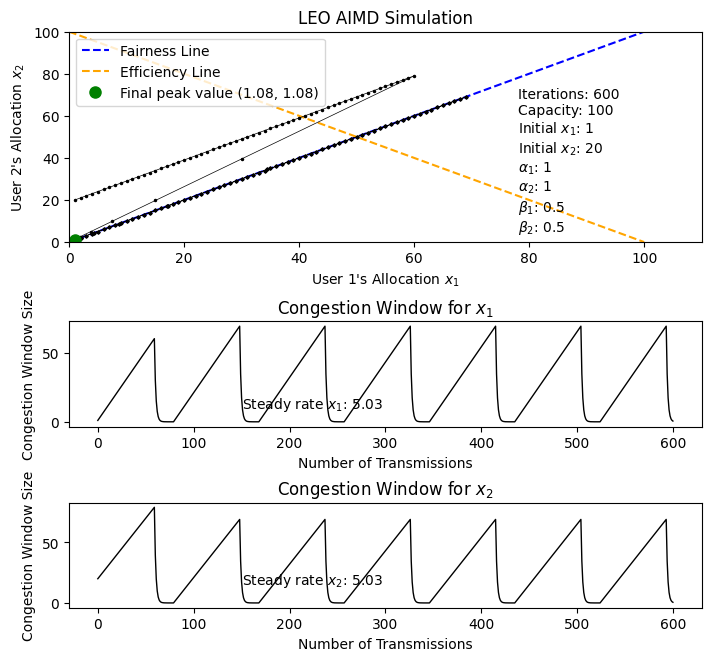

In [6]:
# Run LEO simulation
ITERATESMAX = 600
network_capacity = 100
initial_x1 = 1
initial_x2 = 20
alpha1 = alpha2 = 1
beta1 = beta2 = 0.5
feedback_delay = 20  # LEO RTT in iterations
ber = 0.001          # LEO bit error rate

history_x1, history_x2, latest_x1, latest_x2, average_x1, average_x2, fairness_iteration = aimd_leo(
    network_capacity, initial_x1, initial_x2,
    alpha1, alpha2, beta1, beta2, ITERATESMAX,
    feedback_delay=feedback_delay, ber=ber
)

plot_aimd(
    history_x1, history_x2, latest_x1, latest_x2,
    average_x1, average_x2, network_capacity, ITERATESMAX,
    initial_x1, initial_x2, alpha1, alpha2, beta1, beta2,
    'LEO AIMD Simulation',
    plot2xy=(150, 10), plot3xy=(150, 15)
)

In [ ]:
from collections import deque
import numpy as np
import matplotlib.pyplot as plt

def aimd_ecn_leo(capacity, initial_x1, initial_x2, alpha1, alpha2, beta1, beta2, n_iterations,
             feedback_delay=20, ber=0.001, ecn_threshold=0.80, beta_ecn=0.875):
    # feedback_delay: RTT in iterations (~20ms for LEO)
    # ber: bit error rate causing random non-congestion loss
    # ecn_threshold: fraction of capacity at which ECN marks begin, 80%
    # beta_ecn: gentle decrease factor on ECN signal

    x1, x2 = initial_x1, initial_x2
    history_x1, history_x2 = [x1], [x2]
    latest_x1, latest_x2 = 0, 0
    fairness_iteration = 0
    decreased_iterations = []
    congestion_iterations = [] 
    ecn_cooldown = 0

    # Delayed feedback queue: stores ('loss'/'ecn', x1, x2) or None
    feedback_queue = deque([None] * feedback_delay, maxlen=feedback_delay)

    for i in range(n_iterations):
        # Random bit error loss
        bit_error_loss = np.random.rand() < ber

        # Check congestion and ECN marking now, but queue the signal
        util = x1 + x2
        if util > capacity:
            feedback_queue.append(('loss', x1, x2))
        elif util > ecn_threshold * capacity:
            feedback_queue.append(('ecn', x1, x2))
        else:
            feedback_queue.append(None)

        # React to delayed feedback from feedback_delay iterations ago
        delayed_signal = feedback_queue[0]

        # ECN cooldown
        if ecn_cooldown > 0:
            ecn_cooldown -= 1

        if bit_error_loss:
            # Non-congestion loss: still triggers AIMD decrease, multiplicative decrease
            decreased_iterations.append(i)
            latest_x1, latest_x2 = x1, x2
            x1 *= beta1
            x2 *= beta2

        # handle delayed congestion/ECN signal
        if not bit_error_loss and delayed_signal is not None:
            sig_type, ds_x1, ds_x2 = delayed_signal
            latest_x1, latest_x2 = x1, x2
            decreased_iterations.append(i)
            congestion_iterations.append(i)

            if fairness_iteration == 0 and capacity/2 * 0.95 < latest_x2 < capacity/2 * 1.05:
                fairness_iteration = i

            if sig_type == 'loss':
                x1 *= beta1
                x2 *= beta2
                ecn_cooldown = feedback_delay
            elif sig_type == 'ecn' and ecn_cooldown == 0:
                x1 *= beta_ecn
                x2 *= beta_ecn
                ecn_cooldown = feedback_delay

            # if ecn but cooldown active: fall through to additive increase
            else:
                x1 += alpha1
                x2 += alpha2

        elif not bit_error_loss:
            # No congestion, no loss, additive increase
            x1 += alpha1
            x2 += alpha2

        history_x1.append(x1)
        history_x2.append(x2)

    congestion_iterations = np.array(congestion_iterations)
    decreased_iterations = np.array(decreased_iterations)
    if len(congestion_iterations) > 4:
        window = congestion_iterations[-1] - congestion_iterations[-4]
        steady_x1 = sum(history_x1[int(congestion_iterations[-4]) : int(congestion_iterations[-1])])
        steady_x2 = sum(history_x2[int(congestion_iterations[-4]) : int(congestion_iterations[-1])])
        average_x1 = steady_x1 / window
        average_x2 = steady_x2 / window
    else:
        average_x1 = np.mean(history_x1)
        average_x2 = np.mean(history_x2)

    print(f"Total iterations: {n_iterations}")
    print(f"Feedback delay (RTT): {feedback_delay} iterations")
    print(f"Bit Error Rate: {ber}")
    print(f"Close to fair value at iteration: {fairness_iteration}")
    print(f"Latest x1 and x2 before congestion: {latest_x1:.2f}, {latest_x2:.2f}")
    print(f"Steady rate x1: {average_x1:.2f}")
    print(f"Steady rate x2: {average_x2:.2f}")

    return history_x1, history_x2, latest_x1, latest_x2, average_x1, average_x2, fairness_iteration

Total iterations: 600
Feedback delay (RTT): 20 iterations
Bit Error Rate: 0.001
Close to fair value at iteration: 125
Latest x1 and x2 before congestion: 56.63, 56.63
Steady rate x1: 54.63
Steady rate x2: 54.63


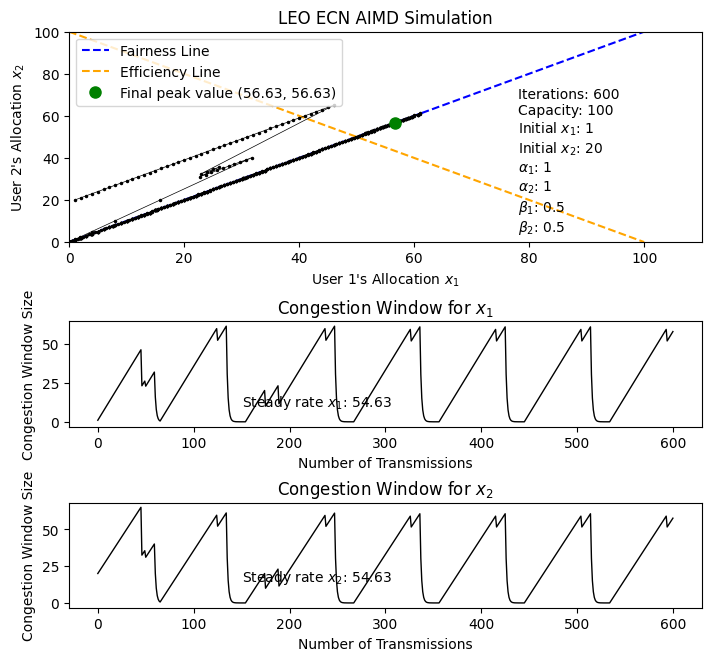

In [ ]:
# Run ECN LEO simulation
ITERATESMAX = 600
network_capacity = 100
initial_x1 = 1
initial_x2 = 20
alpha1 = alpha2 = 1
beta1 = beta2 = 0.5
feedback_delay = 20  # LEO RTT in iterations
ber = 0.001          # LEO bit error rate

history_x1, history_x2, latest_x1, latest_x2, average_x1, average_x2, fairness_iteration = aimd_ecn_leo(
    network_capacity, initial_x1, initial_x2,
    alpha1, alpha2, beta1, beta2, ITERATESMAX,
    feedback_delay=feedback_delay, ber=ber
)

plot_aimd(
    history_x1, history_x2, latest_x1, latest_x2,
    average_x1, average_x2, network_capacity, ITERATESMAX,
    initial_x1, initial_x2, alpha1, alpha2, beta1, beta2,
    'LEO ECN AIMD Simulation',
    plot2xy=(150, 10), plot3xy=(150, 15)
)